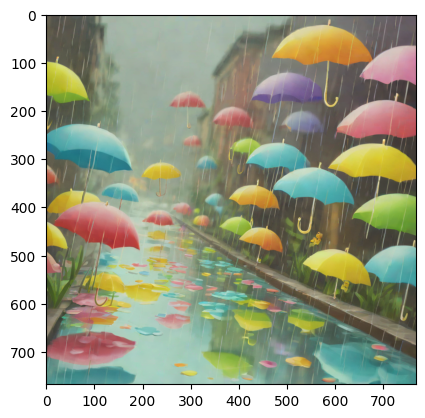

17.376472
[8, 0, 7, 5, 9, 6, 1, 11, 2]


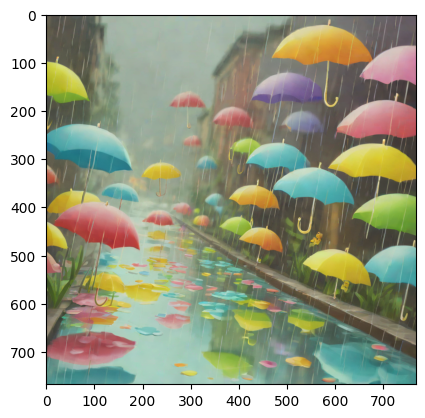

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('/kaggle/input/datasets/aithbb/puzzlesolver/train/train.csv')
val = pd.read_csv('/kaggle/input/datasets/aithbb/puzzlesolver/val/val.csv')
base_train = '/kaggle/input/datasets/aithbb/puzzlesolver/train/'
for i in range(1200):
    row = train.iloc[i].tolist()
    base_sample = base_train+'samples/'+row[0]
    imgs = []
    for j in range(2, 14):
        X = plt.imread(base_sample+'/'+row[j])
        imgs.append(X)
    def vis(names):
        cr = []
        for j in range(9):
            if j % 3 == 0:
                cr.append([])
            cr[-1].append(plt.imread(base_sample+'/'+names[j]))
        cr[0] = np.concatenate(cr[0], axis=1)
        cr[1] = np.concatenate(cr[1], axis=1)
        cr[2] = np.concatenate(cr[2], axis=1)
        plt.imshow(np.concatenate(cr, axis=0))
        plt.show()
    vis(row[14:23])
    mn = 10000
    indCenter = -1
    edgs = []
    for x1 in range(12):
        vals = []
        for x2 in range(12):
            val1 = np.abs(imgs[x1][:, -1] - imgs[x2][:, 0]).sum()
            val2 = np.abs(imgs[x1][:, 0] - imgs[x2][:, -1]).sum()
            val3 = np.abs(imgs[x1][-1] - imgs[x2][0]).sum()
            val4 = np.abs(imgs[x1][0] - imgs[x2][-1]).sum()
            vals.append(min(val1, val2, val3, val4))
        vals.sort()
        if vals[3] < mn:
            mn = vals[3]
            indCenter = x1
    print(mn)
    def findUp(ind):
        mn = 10000
        newind = -1
        for x2 in range(12):
            val4 = np.abs(imgs[ind][0] - imgs[x2][-1]).sum()
            if val4 < mn:
                mn = val4
                newind = x2
        return newind
    def findLeft(ind):
        mn = 10000
        newind = -1
        for x2 in range(12):
            val4 = np.abs(imgs[ind][:, 0] - imgs[x2][:, -1]).sum()
            if val4 < mn:
                mn = val4
                newind = x2
        return newind
    def findDown(ind):
        mn = 10000
        newind = -1
        for x2 in range(12):
            val4 = np.abs(imgs[ind][-1] - imgs[x2][0]).sum()
            if val4 < mn:
                mn = val4
                newind = x2
        return newind
    def findRight(ind):
        mn = 10000
        newind = -1
        for x2 in range(12):
            val4 = np.abs(imgs[ind][:, -1] - imgs[x2][:, 0]).sum()
            if val4 < mn:
                mn = val4
                newind = x2
        return newind
    indUp = findUp(indCenter)
    indRight = findRight(indCenter)
    indLeft = findLeft(indCenter)
    indDown = findDown(indCenter)
    names = [findUp(indLeft), indUp, findUp(indRight), indLeft, indCenter, indRight, findLeft(indDown), indDown, findRight(indDown)]
    print(names)
    for t in range(len(names)):
        names[t] = row[2+names[t]]
    vis(names)
    break

In [2]:
from tqdm.auto import tqdm
test = pd.read_csv('/kaggle/input/datasets/aithbb/puzzlesolver/test/test.csv')
base_test = '/kaggle/input/datasets/aithbb/puzzlesolver/test/'
ans = []
import numpy as np
from scipy.ndimage import distance_transform_edt

def getWhole(X):
    if X.shape[2] == 3:
        return X

    rgb = X[:, :, :3]
    alpha = X[:, :, 3]

    # маска прозрачных пикселей
    mask = alpha == 0

    # если всё норм — возвращаем как есть
    if not np.any(mask):
        return rgb

    # находим ближайшие "живые" пиксели
    _, inds = distance_transform_edt(mask, return_indices=True)

    filled = rgb[inds[0], inds[1]]

    return filled
for i in tqdm(range(len(test))):
    row = test.iloc[i].tolist()
    base_sample = base_test+'samples/'+row[0]
    imgs = []
    for j in range(2, 14):
        X = plt.imread(base_sample+'/'+row[j])
        X = getWhole(X)
        imgs.append(X)
    def vis(names):
        cr = []
        for j in range(9):
            if j % 3 == 0:
                cr.append([])
            cr[-1].append(getWhole(plt.imread(base_sample+'/'+names[j])))
        cr[0] = np.concatenate(cr[0], axis=1)
        cr[1] = np.concatenate(cr[1], axis=1)
        cr[2] = np.concatenate(cr[2], axis=1)
        plt.imshow(np.concatenate(cr, axis=0))
        plt.show()
    # def getdistboks(X1, X2):
    mn = 10000
    indCenter = -1
    edgs = []
    for x1 in range(12):
        vals = []
        for x2 in range(12):
            val1 = np.abs(imgs[x1][:, -1] - imgs[x2][:, 0]).sum()
            val2 = np.abs(imgs[x1][:, 0] - imgs[x2][:, -1]).sum()
            val3 = np.abs(imgs[x1][-1] - imgs[x2][0]).sum()
            val4 = np.abs(imgs[x1][0] - imgs[x2][-1]).sum()
            vals.append(min(val1, val2, val3, val4))
        vals.sort()
        if vals[3] < mn:
            mn = vals[3]
            indCenter = x1
    # print(mn)
    def findUp(ind):
        mn = 10000
        newind = -1
        for x2 in range(12):
            val4 = np.abs(imgs[ind][0] - imgs[x2][-1]).sum()
            if val4 < mn:
                mn = val4
                newind = x2
        return newind
    def findLeft(ind):
        mn = 10000
        newind = -1
        for x2 in range(12):
            val4 = np.abs(imgs[ind][:, 0] - imgs[x2][:, -1]).sum()
            if val4 < mn:
                mn = val4
                newind = x2
        return newind
    def findDown(ind):
        mn = 10000
        newind = -1
        for x2 in range(12):
            val4 = np.abs(imgs[ind][-1] - imgs[x2][0]).sum()
            if val4 < mn:
                mn = val4
                newind = x2
        return newind
    def findRight(ind):
        mn = 10000
        newind = -1
        for x2 in range(12):
            val4 = np.abs(imgs[ind][:, -1] - imgs[x2][:, 0]).sum()
            if val4 < mn:
                mn = val4
                newind = x2
        return newind
    indUp = findUp(indCenter)
    indRight = findRight(indCenter)
    indLeft = findLeft(indCenter)
    indDown = findDown(indCenter)
    names = [findUp(indLeft), indUp, findUp(indRight), indLeft, indCenter, indRight, findLeft(indDown), indDown, findRight(indDown)]
    for t in range(len(names)):
        names[t] = row[2+names[t]]
    ans.append(names)
    # print(imgs[0].max())
    # vis(names)
    # imgs[0][0:5, 0:5, 0] = 1
    # imgs[0][0:5, 0:5, 1] = 0
    # print(imgs[0][0][0])
    # print(imgs[0][0][1])
    # plt.imshow(imgs[0])
    # plt.show()
    # if i >= 5:
    #     break

  0%|          | 0/300 [00:00<?, ?it/s]

In [3]:
sub = pd.DataFrame(ans)
sub.columns = ['piece_00', 'piece_01', 'piece_02', 'piece_03', 'piece_04', 'piece_05', 'piece_06', 'piece_07', 'piece_08']
sub['subtaskID'] = 1
sub['sampleID'] = test['sample_id']
sub.to_csv('submission.csv', index=False)
sub

,piece_00,piece_01,piece_02,piece_03,piece_04,piece_05,piece_06,piece_07,piece_08,subtaskID,sampleID
0,piece_09.png,piece_10.png,piece_00.png,piece_05.png,piece_04.png,piece_08.png,piece_07.png,piece_03.png,piece_11.png,1,test_000000
1,piece_11.png,piece_00.png,piece_03.png,piece_11.png,piece_08.png,piece_07.png,piece_09.png,piece_09.png,piece_10.png,1,test_000001
2,piece_00.png,piece_11.png,piece_06.png,piece_07.png,piece_11.png,piece_05.png,piece_03.png,piece_08.png,piece_05.png,1,test_000002
3,piece_04.png,piece_06.png,piece_09.png,piece_05.png,piece_07.png,piece_11.png,piece_00.png,piece_08.png,piece_01.png,1,test_000003
4,piece_10.png,piece_10.png,piece_01.png,piece_05.png,piece_11.png,piece_09.png,piece_02.png,piece_08.png,piece_00.png,1,test_000004
...,...,...,...,...,...,...,...,...,...,...,...
295,piece_04.png,piece_02.png,piece_03.png,piece_00.png,piece_06.png,piece_08.png,piece_05.png,piece_10.png,piece_09.png,1,test_000295
296,piece_08.png,piece_02.png,piece_07.png,piece_10.png,piece_03.png,piece_00.png,piece_11.png,piece_09.png,piece_06.png,1,test_000296
297,piece_05.png,piece_01.png,piece_08.png,piece_04.png,piece_00.png,piece_11.png,piece_09.png,piece_07.png,piece_03.png,1,test_000297
298,piece_09.png,piece_02.png,piece_05.png,piece_07.png,piece_00.png,piece_01.png,piece_06.png,piece_11.png,piece_03.png,1,test_000298


In [4]:
test

,sample_id,split,piece_00,piece_01,piece_02,piece_03,piece_04,piece_05,piece_06,piece_07,piece_08,piece_09,piece_10,piece_11,subtaskID
0,test_000000,test,piece_00.png,piece_01.png,piece_02.png,piece_03.png,piece_04.png,piece_05.png,piece_06.png,piece_07.png,piece_08.png,piece_09.png,piece_10.png,piece_11.png,NaN
1,test_000001,test,piece_00.png,piece_01.png,piece_02.png,piece_03.png,piece_04.png,piece_05.png,piece_06.png,piece_07.png,piece_08.png,piece_09.png,piece_10.png,piece_11.png,NaN
2,test_000002,test,piece_00.png,piece_01.png,piece_02.png,piece_03.png,piece_04.png,piece_05.png,piece_06.png,piece_07.png,piece_08.png,piece_09.png,piece_10.png,piece_11.png,NaN
3,test_000003,test,piece_00.png,piece_01.png,piece_02.png,piece_03.png,piece_04.png,piece_05.png,piece_06.png,piece_07.png,piece_08.png,piece_09.png,piece_10.png,piece_11.png,NaN
4,test_000004,test,piece_00.png,piece_01.png,piece_02.png,piece_03.png,piece_04.png,piece_05.png,piece_06.png,piece_07.png,piece_08.png,piece_09.png,piece_10.png,piece_11.png,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,test_000295,test,piece_00.png,piece_01.png,piece_02.png,piece_03.png,piece_04.png,piece_05.png,piece_06.png,piece_07.png,piece_08.png,piece_09.png,piece_10.png,piece_11.png,NaN
296,test_000296,test,piece_00.png,piece_01.png,piece_02.png,piece_03.png,piece_04.png,piece_05.png,piece_06.png,piece_07.png,piece_08.png,piece_09.png,piece_10.png,piece_11.png,NaN
297,test_000297,test,piece_00.png,piece_01.png,piece_02.png,piece_03.png,piece_04.png,piece_05.png,piece_06.png,piece_07.png,piece_08.png,piece_09.png,piece_10.png,piece_11.png,NaN
298,test_000298,test,piece_00.png,piece_01.png,piece_02.png,piece_03.png,piece_04.png,piece_05.png,piece_06.png,piece_07.png,piece_08.png,piece_09.png,piece_10.png,piece_11.png,NaN
